In [1]:
import pygraphviz as pgv

causal_graph = """
digraph {
    "Prior Experience" -> "Player Skill Level";
    "Prior Experience" -> "Time Spent Playing";
    "Time Spent Playing" -> "Player Skill Level";
    "Guild Membership" -> "Side-quest Engagement";
    "Guild Membership" -> "In-game Purchases";
    "Player Skill Level" -> "Side-quest Engagement";
    "Player Skill Level" -> "In-game Purchases";
    "Time Spent Playing" -> "Side-quest Engagement";
    "Time Spent Playing" -> "In-game Purchases";
    "Side-quest Group Assignment" -> "Side-quest Engagement";
    "Customization Level" -> "Side-quest Engagement";
    "Side-quest Engagement" -> "Won Items";
    "Won Items" -> "In-game Purchases";
    "Won Items" -> "Total Inventory";
    "In-game Purchases" -> "Total Inventory";
}
"""

In [2]:
from IPython.display import Image

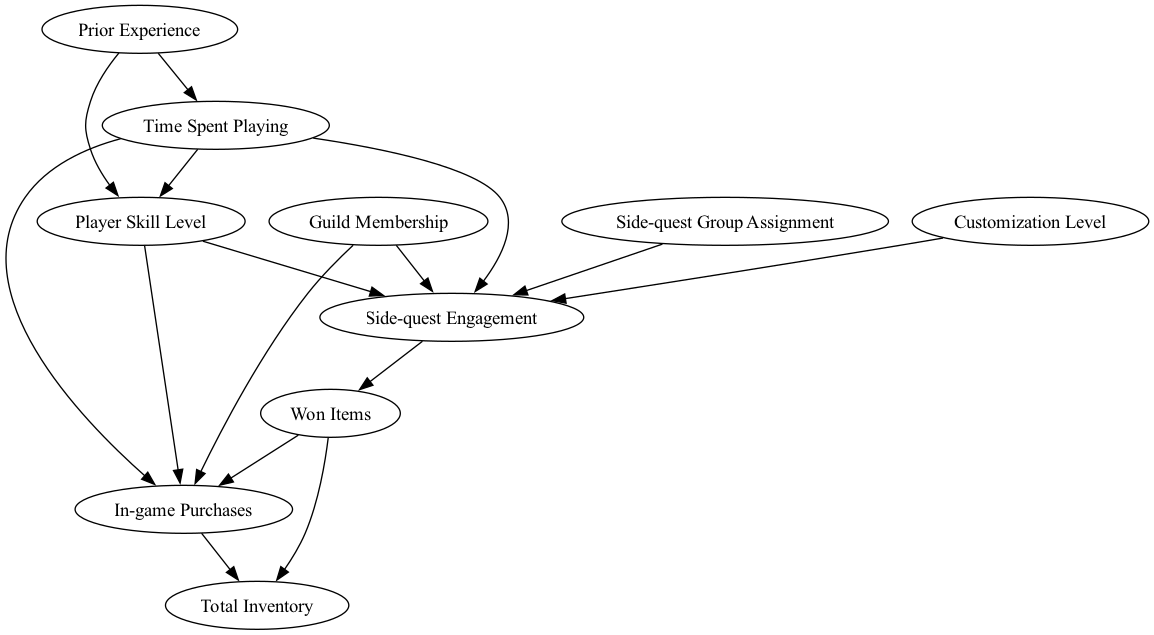

In [3]:
G= pgv.AGraph(string=causal_graph)
G.draw('causal_graph.png', prog='dot')
Image('causal_graph.png')

In [4]:

import pandas as pd
data = pd.read_csv(
    "https://raw.githubusercontent.com/altdeep/causalML/master/datasets/online_game_example_do_why.csv"    #A
)
print(data.columns)   

Index(['Guild Membership', 'Player Skill Level', 'Time Spent Playing',
       'Side-quest Group Assignment', 'Customization Level',
       'Side-quest Engagement', 'Won Items', 'In-game Purchases',
       'Total Inventory'],
      dtype='object')


In [6]:
import dowhy
print(dowhy.__version__)

0.13


In [7]:
from dowhy import CausalModel    #A

model = CausalModel(
    data=data,    #B
    treatment='Side-quest Engagement',    #C
    outcome='In-game Purchases',    #C
    graph=causal_graph    #D
)


/Users/rjljr/miniforge3/envs/causalML/lib/python3.12/site-packages/dowhy/causal_model.py:581: UserWarning: 1 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.
  warnings.warn(


In [8]:
# monkey patch so dowhy will work
#nx.algorithms.d_separated = nx.algorithms.d_separation.is_d_separator
#nx.d_separated = nx.algorithms.d_separation.is_d_separator

identified_estimand = model.identify_effect()   
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
           d                                                                   ↪
────────────────────────(E[In-game Purchases|Guild Membership,Time Spent Playi ↪
d[Side-quest Engagement]                                                       ↪

↪                        
↪ ng,Player Skill Level])
↪                        
Estimand assumption 1, Unconfoundedness: If U→{Side-quest Engagement} and U→In-game Purchases then P(In-game Purchases|Side-quest Engagement,Guild Membership,Time Spent Playing,Player Skill Level,U) = P(In-game Purchases|Side-quest Engagement,Guild Membership,Time Spent Playing,Player Skill Level)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                             ↪
 ⎢                         d                                             ⎛     ↪
E⎢─────────────────────────────────────────────────